# LSTM

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
# from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau 

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Import Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
# Normalize the data 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [4]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15

target_col_idx = data.columns.get_loc("close")
X, y = create_sequences(data_normalized, window_size, target_col_idx=target_col_idx)

### Split

In [5]:
split = int(len(X) * 0.8)  # 80% training, 20% testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (47062, 15, 4)
y_train shape: (47062,)
X_test shape: (11766, 15, 4)
y_test shape: (11766,)


## LSTM 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,231 (16.53 KB)

 Trainable params: 4,231 (16.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0109 - val_loss: 0.0017
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - val_loss: 8.0699e-04
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 9.0705e-04
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.9246e-04 - val_loss: 8.2785e-04
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.2760e-04 - val_loss: 9.5717e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.8733e-04 - val_loss: 5.6073e-04
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.8447e-04 - val_loss: 6.1544e-04
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.2855e-04 - val_loss: 3.8175e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.4057e-04 - val_loss: 5.1249e-04
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.2580e-04 - val_loss:

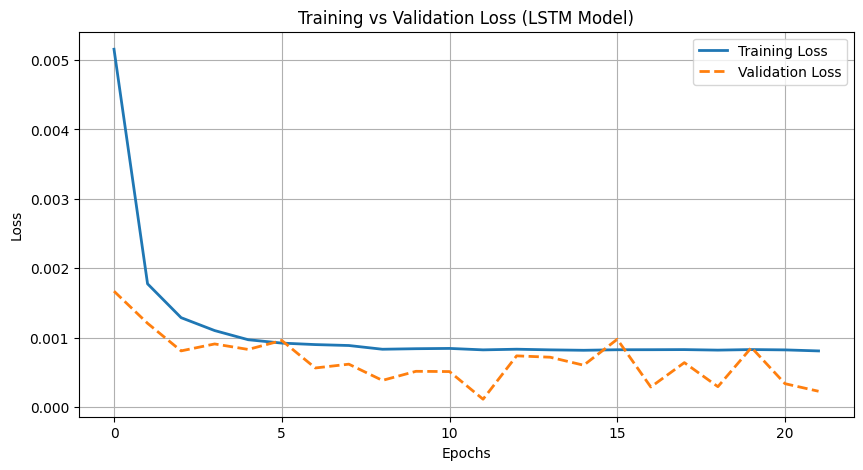

368/368 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step
Model Error Statistics:
Mean Absolute Error (MAE): 671.5323
Root Mean Squared Error (RMSE): 1103.5551
Mean Absolute Percentage Error (MAPE): 0.91%


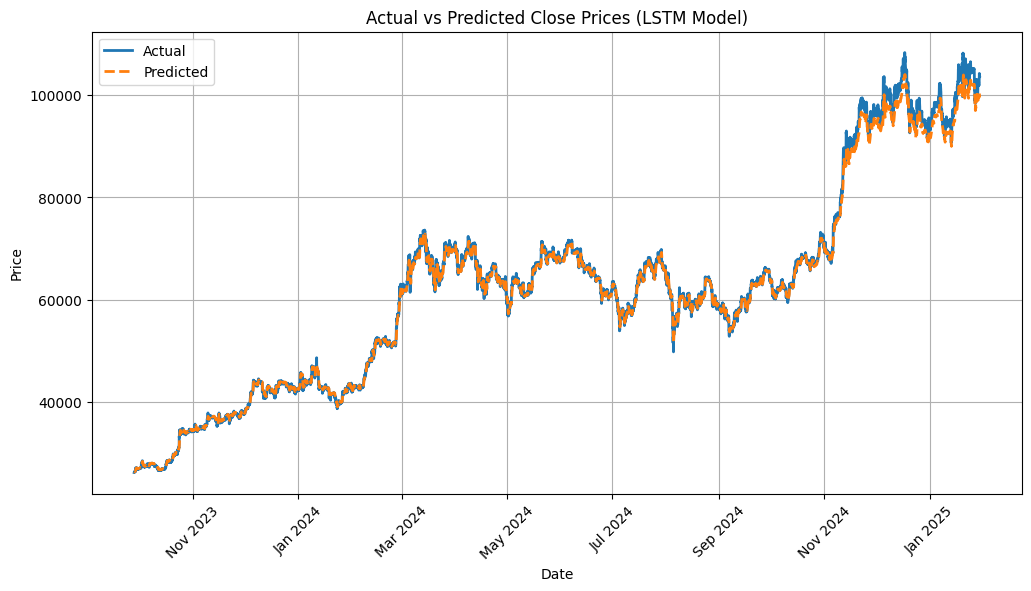

In [6]:
# LSTM Model 
lstm_model = Sequential()

# One LSTM layer
lstm_model.add(LSTM(30, return_sequences=False, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.5))  

# Output layer
lstm_model.add(Dense(1))

# Compile the model 
optimizer = tf.keras.optimizers.Adam()
lstm_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
lstm_model.summary()

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the LSTM model with Early Stopping
history = lstm_model.fit(X_train, y_train, 
                        epochs=50,  # Increased for better learning
                        batch_size=256,  # Increased for smoother validation loss
                        validation_data=(X_test, y_test), 
                        callbacks=[early_stopping],  
                        verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (LSTM Model)')
plt.legend()
plt.grid(True)
plt.show()

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_lstm = lstm_model.predict(X_test)

# Inverse transform predictions
predicted_lstm = close_scaler.inverse_transform(predicted_lstm.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_lstm)
mse = mean_squared_error(y_test_actual, predicted_lstm)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_lstm) / y_test_actual)) * 100  

# Print results
print(f"Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_lstm, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (LSTM Model)')
plt.xlabel('Date')
plt.ylabel('Price')

# Format x-axis to show Month-Year
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()